# Пример расследования: «Поймай статистику, которая врёт»
### YDL 2026 · Неделя 2 · День 1 · разбор

Перед нами `ydl_grads.csv`, выдуманные данные о 220 выпускниках буткемпа: трек, город, возраст,
опыт в месяцах, часы в неделю, зарплата, удовлетворённость, отметка об отклике на опрос и несколько
шумовых колонок.

Правило игры одно: **мы не верим ни одному числу, пока не проверили, откуда оно взялось.**
Ниже мы пройдём задание лабы по шагам и поймаем пять разных способов, которыми статистика врёт.

In [1]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('ydl_grads.csv')
print('строк:', len(df), '  колонок:', df.shape[1])
df.head()

строк: 221   колонок: 16


,track,city,age,experience_months,weekly_hours,salary,satisfaction,responded,noise1,noise2,noise3,noise4,noise5,noise6,noise7,noise8
0,Веб-разработка,Караганда,25,24,41.3,556000,NaN,0,-0.705,1.262,0.512,-1.578,-1.073,0.269,2.034,-0.862
1,Аналитика данных,Астана,28,0,25.7,899000,NaN,1,-0.417,-0.257,-0.970,0.494,0.281,0.492,0.279,-0.398
2,Веб-разработка,Алматы,29,2,51.2,658000,6.1,1,0.363,1.326,-1.140,-0.550,-0.508,-0.272,1.014,1.672
3,Веб-разработка,Караганда,29,16,40.5,507000,5.3,1,0.702,0.188,1.526,1.114,-1.360,-0.974,0.768,-1.153
4,Веб-разработка,Шымкент,29,20,39.8,512000,6.9,0,0.467,-0.002,0.182,0.311,-0.069,0.258,-1.485,-1.059


In [3]:
df['track'].unique()

array(['Веб-разработка', 'Аналитика данных', 'Мобильная разработка',
       'Своё дело'], dtype=object)

In [4]:
df['track'].value_counts()

track
Веб-разработка          82
Аналитика данных        70
Мобильная разработка    60
Своё дело                9
Name: count, dtype: int64

## Задание 1. Допросите одну колонку: зарплата

Считаем сводку. Не глядим на неё как на формальность, сравниваем среднее и медиану.

In [2]:
df['salary'].describe().round(0)

count        221.0
mean      756751.0
std       716133.0
min       215000.0
25%       452000.0
50%       574000.0
75%       878000.0
max      4614000.0
Name: salary, dtype: float64

In [5]:
print('среднее :', round(df.salary.mean()))
print('медиана :', round(df.salary.median()))
print('отношение среднее/медиана:', round(df.salary.mean()/df.salary.median(), 2))

среднее : 756751
медиана : 574000
отношение среднее/медиана: 1.32


### Ловушка №1: среднее завышено перекосом

Среднее (около 757 000) заметно больше медианы (около 574 000). Когда они так расходятся, данные
перекошены, и среднее уже не «типичный выпускник». Посмотрим на гистограмму и на тех, кто тянет хвост.

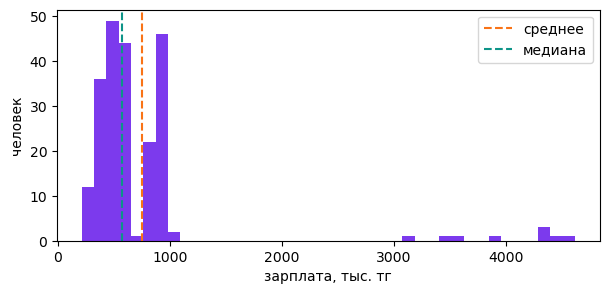

In [6]:
fig, ax = plt.subplots(figsize=(7,3))
ax.hist(df.salary/1000, bins=40, color='#7C3AED')
ax.axvline(df.salary.mean()/1000, color='#F97316', linestyle='--', label='среднее')
ax.axvline(df.salary.median()/1000, color='#0D9488', linestyle='--', label='медиана')
ax.set_xlabel('зарплата, тыс. тг'); ax.set_ylabel('человек'); ax.legend()
plt.show()

In [10]:
# проверяем руками: кто в правом хвосте?
df.nlargest(9, 'salary')[['track','weekly_hours','salary']]

,track,weekly_hours,salary
126,Своё дело,47.0,4614000
128,Своё дело,46.9,4490000
102,Своё дело,29.6,4391000
193,Своё дело,33.7,4349000
109,Своё дело,24.0,4323000
22,Своё дело,31.1,3924000
104,Своё дело,33.1,3610000
118,Своё дело,35.0,3441000
54,Своё дело,34.9,3183000


Хвост это девять человек из трека «Своё дело» с зарплатами в миллионы. Их всего 9 из 220,
но они утягивают среднее вверх. Честный ответ про «типичного выпускника» даёт **медиана**.

То же видно через группировку: средняя по «Своё дело» огромная, и она искажает общую среднюю.

In [11]:
df.groupby('track')['salary'].agg(['count','mean','median']).round(0)

,count,mean,median
track,,,
Аналитика данных,70,895243.0,896000.0
Веб-разработка,82,553134.0,555000.0
Мобильная разработка,60,381550.0,389000.0
Своё дело,9,4036111.0,4323000.0


## Ловушка №2: пропуски, которые молчат

Посчитаем среднюю удовлетворённость. Но сначала спросим: по скольким строкам она вообще считается?

In [13]:
df.satisfaction

0      NaN
1      NaN
2      6.1
3      5.3
4      6.9
      ... 
216    6.7
217    8.1
218    7.9
219    6.9
220    4.6
Name: satisfaction, Length: 221, dtype: float64

In [14]:
df['satisfaction']

0      NaN
1      NaN
2      6.1
3      5.3
4      6.9
      ... 
216    6.7
217    8.1
218    7.9
219    6.9
220    4.6
Name: satisfaction, Length: 221, dtype: float64

In [12]:
print('средняя удовлетворённость:', round(df.satisfaction.mean(), 2))
print('ответили:', df.satisfaction.notna().sum(), '   молчат:', df.satisfaction.isna().sum())

средняя удовлетворённость: 6.51
ответили: 156    молчат: 65


In [15]:
# кто именно не ответил? сравним зарплату ответивших и молчащих
df.groupby(df.satisfaction.isna())['salary'].median().rename({False:'ответили', True:'молчат'}).round(0)

satisfaction
ответили    606000.0
молчат      505000.0
Name: salary, dtype: float64

Удовлетворённость «6.5» посчитана не по всем. Молчат в основном люди с низкой зарплатой,
а это как раз недовольные. Среднее по ответившим выглядит хорошо именно потому, что недовольные
выпали из выборки. Число честное по арифметике, но врёт по сути.

## Задание 2. Одна корреляция: часы и зарплата

In [21]:
r = df['weekly_hours'].corr(df['salary'])
print('корреляция часов и зарплаты по всем данным: r =', round(r, 2))

корреляция часов и зарплаты по всем данным: r = -0.32


### Ловушка №3: парадокс Симпсона

Получилось `r = -0.32`. Буквально: чем больше человек работает, тем меньше зарабатывает. Звучит дико,
поэтому не верим и режем по треку.

In [22]:
df.groupby('track')[['weekly_hours', 'salary']].apply(
    lambda g: round(g.weekly_hours.corr(g.salary), 2)
).rename('r внутри трека')

track
Аналитика данных        0.88
Веб-разработка          0.89
Мобильная разработка    0.88
Своё дело               0.26
Name: r внутри трека, dtype: float64

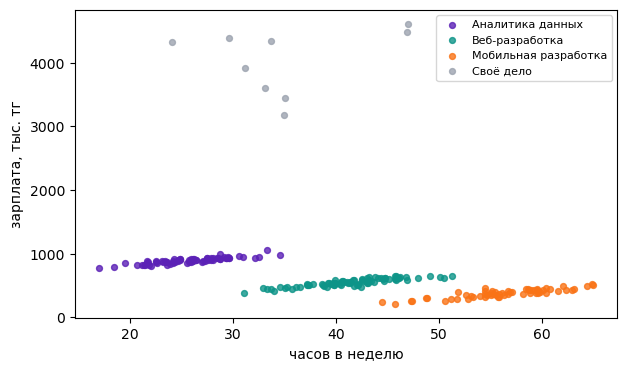

In [23]:
# покажем глазами: внутри каждого трека связь идёт вверх, а общий тренд вниз
colors = {'Аналитика данных':'#5B21B6','Веб-разработка':'#0D9488',
          'Мобильная разработка':'#F97316','Своё дело':'#9CA3AF'}
fig, ax = plt.subplots(figsize=(7,4))
for tr, g in df.groupby('track'):
    ax.scatter(g.weekly_hours, g.salary/1000, s=18, color=colors[tr], label=tr, alpha=0.8)
ax.set_xlabel('часов в неделю'); ax.set_ylabel('зарплата, тыс. тг'); ax.legend(fontsize=8)
plt.show()

Внутри каждого трека связь **положительная** (около +0.88): больше часов, выше зарплата. Но треки
стоят лесенкой: аналитики работают меньше часов и получают больше, мобильщики наоборот. Когда мы
смешали треки в одну кучу, эта лесенка перевернула общий знак. Это парадокс Симпсона. Вывод «больше
работаешь, меньше платят» был артефактом смешения групп.

## Ловушка №4: смещение выборки

Представим, что зарплату мы узнали из опроса, и берём только тех, кто откликнулся.

In [24]:
print('средняя по всем           :', round(df.salary.mean()))
print('средняя по откликнувшимся  :', round(df[df.responded==1].salary.mean()))
print('завышение опроса           :', str(round(100*(df[df.responded==1].salary.mean()/df.salary.mean()-1)))+'%')

средняя по всем           : 756751
средняя по откликнувшимся  : 873024
завышение опроса           : 15%


Опрос показывает зарплату примерно на 15% выше реальной. Причина: охотнее отвечают те, у кого
зарплата высокая. Это тот же «опрос выживших», кривая выборка дала кривой вывод.

## Бонус: z-score и выбросы

Стандартизуем зарплату и вытащим точки, где значение далеко от среднего.

In [25]:
z = (df.salary - df.salary.mean()) / df.salary.std()
df.assign(z=z.round(2)).loc[z.abs() > 3, ['track','weekly_hours','salary','z']]

,track,weekly_hours,salary,z
22,Своё дело,31.1,3924000,4.42
54,Своё дело,34.9,3183000,3.39
102,Своё дело,29.6,4391000,5.07
104,Своё дело,33.1,3610000,3.98
109,Своё дело,24.0,4323000,4.98
118,Своё дело,35.0,3441000,3.75
126,Своё дело,47.0,4614000,5.39
128,Своё дело,46.9,4490000,5.21
193,Своё дело,33.7,4349000,5.02


Все выбросы это «Своё дело». Те самые девять человек, что портили среднюю в Задании 1. z-score
нашёл их автоматически.

## Особый вызов: охота на призрак

В данных есть восемь чисто случайных колонок `noise1` ... `noise8`. Они ни с чем не связаны по
построению. Переберём все их пары и поищем самую «значимую» корреляцию.

In [26]:
noise = [f'noise{i}' for i in range(1, 9)]
res = []
for i in range(len(noise)):
    for j in range(i+1, len(noise)):
        r, p = stats.pearsonr(df[noise[i]], df[noise[j]])
        res.append((noise[i], noise[j], round(r, 3), round(p, 3)))
res = pd.DataFrame(res, columns=['A','B','r','p']).sort_values('p')
res.head(5)

,A,B,r,p
6,noise1,noise8,0.149,0.027
14,noise3,noise5,0.147,0.029
25,noise6,noise7,0.125,0.063
16,noise3,noise7,-0.123,0.068
19,noise4,noise6,0.120,0.075


Лучшая пара даёт `r ≈ 0.15` и `p ≈ 0.03`, формально «значимо» (p меньше 0.05). Но мы своими руками
сделали эти колонки случайными, связи там нет. Мы просто проверили 28 пар, и одна случайно прошла порог.

Это **p-hacking**: если перебрать достаточно гипотез, что-нибудь всегда выскочит «значимым». Именно так
рождаются ложные открытия, и ровно поэтому модель с R² = 0.99 на подогнанных признаках может оказаться
пустышкой. Самое ценное здесь не найденная корреляция, а понимание, почему ей нельзя верить.

## Что мы поймали

1. **Среднее зарплаты** завышено горсткой основателей. Честный ответ даёт медиана.
2. **Средняя удовлетворённость** посчитана без недовольных, они просто не ответили.
3. **Корреляция часов и зарплаты** перевернулась из-за смешения треков (парадокс Симпсона).
4. **Опрос** завысил зарплату, потому что отвечали в основном высокооплачиваемые.
5. **«Значимая» корреляция** между случайными колонками оказалась призраком (p-hacking).

Пять чисел, и каждое звучало убедительно. Ни одному нельзя было верить без проверки. Это и есть работа
сегодняшнего дня.